In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import math

%matplotlib inline

<h4 style='color:purple'>Load the Dataset</h4>

In [6]:
import pandas as pd

df = pd.read_csv('fraud_oracle.csv')

df = df.drop_duplicates()
df = df.dropna()

X = df.drop(['FraudFound_P', 'PolicyNumber'], axis=1)
y = df['FraudFound_P']
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Dataset shape after cleaning and encoding: {X_encoded.shape}")
display(df.head())

Dataset shape after cleaning and encoding: (15420, 123)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


<h4 style='color:purple'>Create and train logistic regression model</h4>

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)
print("Model training complete with scaling.")

Model training complete with scaling.


<h4 style='color:purple'>Measure accuracy of our model</h4>

In [11]:
accuracy = model.score(X_test_scaled, y_test)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9355


In [ ]:
model.predict(X_test[:5])

array([0, 0, 0, 0, 0])

<h4 style='color:purple'>Confusion Matrix</h4>

In [12]:
from sklearn.metrics import confusion_matrix

y_predicted = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_predicted)

print("Model Intercept:", model.intercept_)
print("First 10 Model Coefficients:", model.coef_[0][:10])

print("\nPrediction Probabilities (first 5 samples):")
display(model.predict_proba(X_test_scaled[:5]))

Model Intercept: [-3.75808554]
First 10 Model Coefficients: [-0.02763423  0.0060504  -0.15235855 -0.02072272  0.00861185  0.02613657
 -0.06998352  0.02712851  0.04396951  0.06864177]

Prediction Probabilities (first 5 samples):


array([[0.93506179, 0.06493821],
       [0.99292601, 0.00707399],
       [0.90283873, 0.09716127],
       [0.77631499, 0.22368501],
       [0.84392347, 0.15607653]])

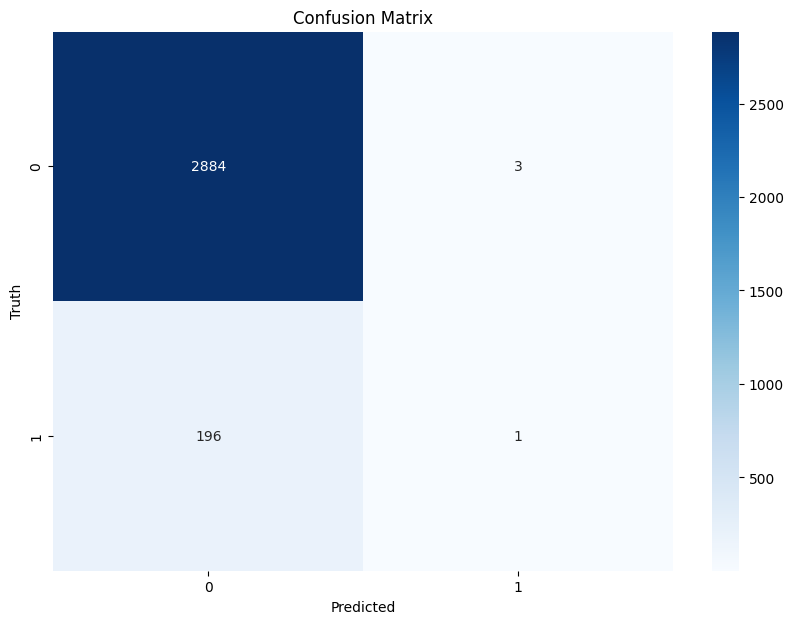

Sigmoid of 0: 0.5
This function represents the activation used in Logistic Regression to map outputs to probabilities.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sn
import math

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()

def sigmoid(x):
  return 1 / (1 + math.exp(-x))

print(f"Sigmoid of 0: {sigmoid(0)}")
print("This function represents the activation used in Logistic Regression to map outputs to probabilities.")